# Exp 2 — Deterministic rules baseline (V2, semantic edition)
**Question:** how much of expense compliance can ordinary code solve, with no AI, once every decision-critical fact lives in free text instead of a structured form?

**Systems (no LLM, cost $0):**
- **2a, as-is:** `src/rules.py`, the earliest rules (constants mostly from the V1 policy), unchanged.
- **2b, frozen V2 rules:** `src/rules_v2.py`, written from the V2 policy text and tuned on the *easy* V2 (100% there, 30/30 on its validation split). Frozen: not touched for this run. It reads structured form fields, which no longer exist, so wherever a field is missing it falls back to defaults or crashes (a crash is scored as ESCALATE).
- **2c, rules + regex text parsing** (patterns written on round-1 notes; from round 3 it also looks the merchant up in the merchant directory because the bill category is coarse): `src/rules_text.py` rebuilds the structured facts from the note with regular expressions (number words, dates, keywords) and then calls the frozen 2b logic. This is the strongest deterministic baseline: it tells us how much of the new difficulty is only "parsing".

**Data:** 70 development claims for the main comparison, then the same three systems on the 30 unseen validation claims. Final test untouched.
**Honesty note on 2c:** its patterns were written after reading development notes, so its dev score is optimistic; validation is the fair number. Nothing here is tuned on validation.

In [1]:
import json, sys, time, uuid
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parents[1]; sys.path.insert(0, str(ROOT))
from src import config as C, llm, rules, rules_v2, rules_text, evaluate, metrics_ext
pd.set_option('display.width', 250, 'display.max_columns', 40, 'display.max_colwidth', 100, 'display.max_rows', 200)
EXP = 'EXP02_RULES'; OUT = C.RESULTS/'development'/'exp02_rules'; OUT.mkdir(parents=True, exist_ok=True)
gt = evaluate.load_gt()
def load(split): return [json.loads(l) for l in (C.CASES/f'{split.lower()}.jsonl').read_text().splitlines() if l.strip()]
def run(name, fn, split):
    recs = []; run_id = f'{EXP}-{name}-{split}-{uuid.uuid4().hex[:6]}'; crashes = 0
    for c in load(split):
        t0 = time.perf_counter()
        try: d = fn(c); err = None
        except Exception as e: d = {'decision':'ESCALATE','policy_evidence':[],'missing_fields':[],'reason':'crash','manual_review_required':True}; err = repr(e)[:150]; crashes += 1
        ms = (time.perf_counter()-t0)*1000
        r = {'case_id':c['case_id'],'predicted_decision':d['decision'],'policy_evidence':d['policy_evidence'],'missing_fields':d['missing_fields'],'reason':d.get('reason'),
             'manual_review_required':d['manual_review_required'],'latency_ms':round(ms,3),'input_tokens':0,'output_tokens':0,'model_cost_usd':0.0,'error':err}
        recs.append(r)
        llm.log_event(type='case_result', run_id=run_id, experiment=EXP, split=split, model=name, **{k:v for k,v in r.items() if k!='case_id'}, case_id=c['case_id'])
    summary, rows = evaluate.evaluate(recs, gt); ext = metrics_ext.extended(recs, gt); summary['crashes_scored_as_escalate'] = crashes
    llm.log_event(type='experiment_summary', run_id=run_id, experiment=EXP, split=split, model=name, config={'rules': name, 'dataset': 'semantic'}, **summary)
    tag = f'{name}_{split.lower()}'
    (OUT/f'predictions_{tag}.jsonl').write_text('\n'.join(json.dumps(r) for r in recs)+'\n'); (OUT/f'evaluation_{tag}.jsonl').write_text('\n'.join(json.dumps(r) for r in rows)+'\n')
    (OUT/f'summary_{tag}.json').write_text(json.dumps({'run_id':run_id, **summary, 'extended':ext}, indent=1, default=str))
    return summary, recs, rows, ext
SYS = {'2a as-is': rules.decide, '2b frozen V2 rules': rules_v2.decide, '2c rules + regex parsing': rules_text.decide}
dev = {k: run(k.split()[0]+'_'+('asis' if k.startswith('2a') else 'frozen' if k.startswith('2b') else 'regex'), fn, 'DEVELOPMENT') for k, fn in SYS.items()}
print({k:(v[0]['correct'], v[0]['n']) for k, v in dev.items()})

{'2a as-is': (22, 70), '2b frozen V2 rules': (34, 70), '2c rules + regex parsing': (48, 70)}


## Comparison table, development (70 claims): standard metrics

In [2]:
def row(k, s): return {'system':k, 'correct/N':f"{s['correct']}/{s['n']}", 'CDR':s['correct_disposition_rate'], 'Wilson95':s['wilson95'], 'false_approvals':f"{s['false_approvals']}/{s['non_approvable']}",
        'FAR':s['false_approval_rate'], 'human_review_rate':s['human_review_rate'], 'crashes':s['crashes_scored_as_escalate'], 'median_ms':s['median_latency_ms'], 'p95_ms':s['p95_latency_ms'], 'cost_usd':s['total_cost_usd']}
pd.DataFrame([row(k, v[0]) for k, v in dev.items()])

,system,correct/N,CDR,Wilson95,false_approvals,FAR,human_review_rate,crashes,median_ms,p95_ms,cost_usd
0,2a as-is,22/70,0.3143,"(0.2176, 0.4303)",39/52,0.7500,0.0286,0,0.0860,0.096,0.0
1,2b frozen V2 rules,34/70,0.4857,"(0.3725, 0.6005)",15/52,0.2885,0.4857,5,1.4375,1.553,0.0
2,2c rules + regex parsing,48/70,0.6857,"(0.5697, 0.7824)",6/52,0.1154,0.1571,0,1.0930,2.021,0.0


## Extended metrics (macro-F1, wrongful rejection, escalation errors, error among auto-resolved, citation, missing-field P/R)

In [3]:
pd.DataFrame([{'system':k, **metrics_ext.table(v[3])} for k, v in dev.items()])

,system,macro_F1,wrongful_reject,over_escal_rate,missed_escal_rate,err_among_auto,cite_prec,cite_rec,mf_prec,mf_rec,cost/correct
0,2a as-is,0.258,0/18,0.0000,0.8824,0.7059,0.3750,0.0357,0.167,0.125,0.0
1,2b frozen V2 rules,0.437,0/18,0.2571,0.0588,0.5000,0.4359,0.1076,0.571,0.250,0.0
2,2c rules + regex parsing,0.687,2/18,0.0000,0.3529,0.3729,0.6545,0.2677,0.333,0.625,0.0


In [4]:
for k, v in dev.items():
    print(k); print(pd.DataFrame(v[3]['per_class']).T.round(3).to_string(), '\n')

2a as-is
                     support  precision  recall     f1
APPROVE                 18.0      0.278   0.833  0.417
REJECT                  19.0      1.000   0.105  0.190
REQUEST_INFORMATION     16.0      0.250   0.188  0.214
ESCALATE                17.0      1.000   0.118  0.211 

2b frozen V2 rules
                     support  precision  recall     f1
APPROVE                 18.0      0.423   0.611  0.500
REJECT                  19.0      1.000   0.158  0.273
REQUEST_INFORMATION     16.0      0.571   0.250  0.348
ESCALATE                17.0      0.471   0.941  0.627 

2c rules + regex parsing
                     support  precision  recall     f1
APPROVE                 18.0      0.600   0.500  0.545
REJECT                  19.0      0.800   0.632  0.706
REQUEST_INFORMATION     16.0      0.552   1.000  0.711
ESCALATE                17.0      1.000   0.647  0.786 



## Where the systems succeed and fail (development)

In [5]:
def fam_table(k):
    d = pd.DataFrame(dev[k][2]); return d.groupby('case_family').correct.agg(['sum','count']).rename(columns={'sum':k.split()[0]+' ok','count':'n'})
fam = fam_table('2a as-is').join(fam_table('2b frozen V2 rules').drop(columns='n')).join(fam_table('2c rules + regex parsing').drop(columns='n'))
fam['group'] = pd.DataFrame(dev['2a as-is'][2]).groupby('case_family').architecture_group.first(); print(fam.sort_values('n', ascending=False).to_string())
grp = pd.concat({k.split()[0]: pd.DataFrame(v[2]).groupby('architecture_group').correct.agg(['sum','count']) for k, v in dev.items()}, axis=1); print(); print(grp)

                              2a ok  n  2b ok  2c ok             group
case_family                                                           
HOTEL_CEILING                     3  7      0      6        B_WORKFLOW
DYNAMIC_HOTEL_DISCOVERY           0  5      4      4   C_AGENT_DYNAMIC
APPROVAL_TIERS                    1  5      5      2        B_WORKFLOW
DYNAMIC_DELEGATION_CHAIN          1  5      5      2   C_AGENT_DYNAMIC
TRAINING_CAP                      3  4      3      4        B_WORKFLOW
SPLIT_TRANSACTION                 0  4      1      4        B_WORKFLOW
HOTEL_EXCEPTION                   0  3      1      2        B_WORKFLOW
GIFT_ANNUAL_CAP                   2  3      2      3        B_WORKFLOW
EMPLOYEE_MEAL_TEMPORAL            1  3      1      1  A_SELF_CONTAINED
AIRFARE_CABIN                     0  3      0      1        B_WORKFLOW
DUPLICATE_CHECK                   3  3      2      2        B_WORKFLOW
SUBMISSION_WINDOW                 2  2      2      2  A_SELF_CONTAINED
ALCOHO

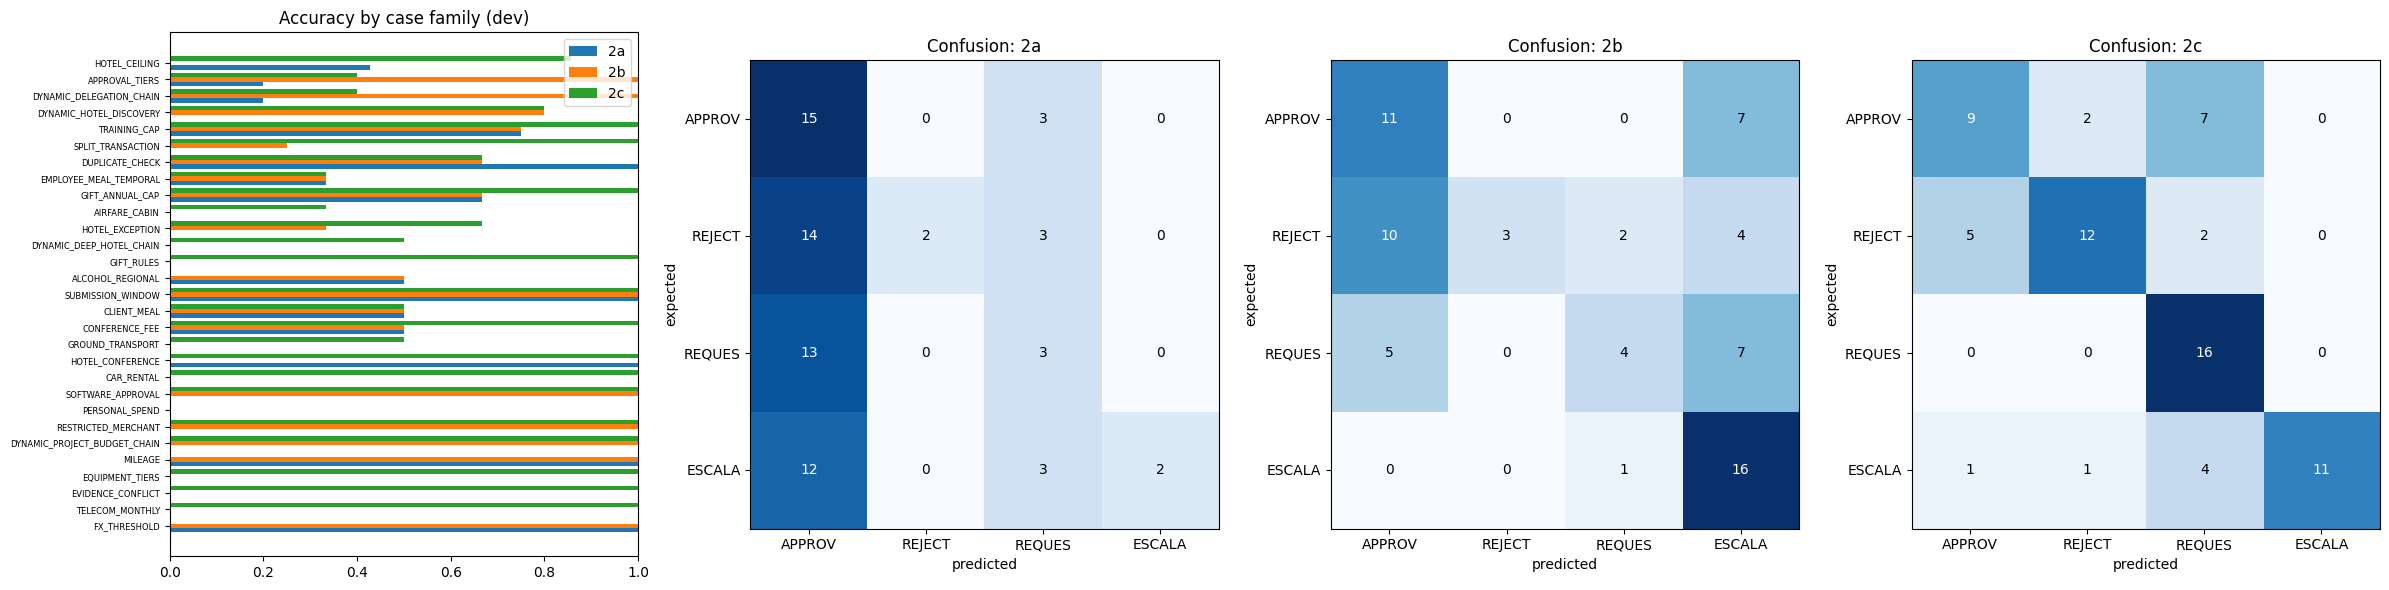

In [6]:
D = ['APPROVE','REJECT','REQUEST_INFORMATION','ESCALATE']
fig, ax = plt.subplots(1, 4, figsize=(24, 6))
f2 = fam.sort_values('n'); h = .27; y = np.arange(len(f2))
for j, col in enumerate(['2a ok','2b ok','2c ok']): ax[0].barh(y + (j-1)*h, f2[col]/f2.n, height=h, label=col[:2])
ax[0].set_yticks(y); ax[0].set_yticklabels(f2.index, fontsize=6); ax[0].set_xlim(0,1); ax[0].legend(); ax[0].set_title('Accuracy by case family (dev)')
for a, k in zip(ax[1:], dev):
    m = pd.crosstab(pd.Categorical([r['expected_decision'] for r in dev[k][2]], D), pd.Categorical([r['predicted_decision'] for r in dev[k][2]], D), dropna=False).values
    a.imshow(m, cmap='Blues'); a.set_xticks(range(4)); a.set_yticks(range(4)); a.set_xticklabels([d[:6] for d in D]); a.set_yticklabels([d[:6] for d in D]); a.set_xlabel('predicted'); a.set_ylabel('expected'); a.set_title('Confusion: '+k.split()[0])
    for i in range(4):
        for j in range(4): a.text(j, i, m[i,j], ha='center', va='center', color='w' if m[i,j] > m.max()/2 else 'k')
plt.tight_layout(); (C.RESULTS/'plots').mkdir(parents=True, exist_ok=True); plt.savefig(C.RESULTS/'plots'/'exp02_rules_development.png', dpi=130); plt.show()

## Failure analysis

In [7]:
kinds = {}
for k in dev:
    d = pd.DataFrame(dev[k][2]); bad = d[~d.correct]
    kinds[k.split()[0]] = {'failures': len(bad), 'false approvals': int((bad.predicted_decision=='APPROVE').sum()), 'wrongful rejections': int((bad.predicted_decision=='REJECT').sum()), 'wrong review/escalation route': int(bad.predicted_decision.isin(['REQUEST_INFORMATION','ESCALATE']).sum())}
print(pd.DataFrame(kinds).to_string())
d = pd.DataFrame(dev['2c rules + regex parsing'][2]); r = {x['case_id']:x['reason'] for x in dev['2c rules + regex parsing'][1]}; d['reason'] = d.case_id.map(r)
notes = {c['case_id']: c['employee_description'] for c in load('DEVELOPMENT')}; d['note'] = d.case_id.map(notes).str[:170]
print('\n2c failures on dev:'); d[~d.correct][['case_id','case_family','expected_decision','predicted_decision','reason','note']]

                               2a  2b  2c
failures                       48  36  22
false approvals                39  15   6
wrongful rejections             0   0   3
wrong review/escalation route   9  21  13

2c failures on dev:


,case_id,case_family,expected_decision,predicted_decision,reason,note
0,X2-003,FX_THRESHOLD,APPROVE,REQUEST_INFORMATION,Named business owner required.,"Softw subscription at Vector Notes (Tokyo, Japan) for Devi Lim, billed mthly. JPY."
7,X2-012,HOTEL_EXCEPTION,REJECT,APPROVE,No rule triggered.,"I booked a stay at Harbour Osaka Hotel in Osaka, Japan, from November eighth to November tenth, ..."
8,X2-013,PERSONAL_SPEND,REJECT,APPROVE,No rule triggered.,Please find the receipt for a charge related to the renewal of MovieBox+. This service is quite ...
9,X2-015,APPROVAL_TIERS,ESCALATE,REQUEST_INFORMATION,Attendee count needed.,"I hosted a meal for some delegates of Omnia Retail at Tokyo Teppan in Japan. It was me, six of m..."
14,X2-028,AIRFARE_CABIN,REJECT,REQUEST_INFORMATION,Description conflicts with the bill category.,"Airfare purchase from Lotus Air (SGD), booked 2026-01-19, departs 21 days later, biz class, 8.0 ..."
15,X2-029,HOTEL_CEILING,APPROVE,REJECT,Nightly rate 57036 exceeds ceiling 19600; no valid exception.,Please find the receipt for hotel accommodation during the recent trip. The stay was at Royal Mu...
21,X2-047,DYNAMIC_DELEGATION_CHAIN,APPROVE,REQUEST_INFORMATION,Attendee count needed.,I hosted a meal for delegates from Ember Foods at Raffles Grill in Singapore. Present were mysel...
22,X2-048,ALCOHOL_REGIONAL,APPROVE,REQUEST_INFORMATION,Attendee count needed.,"I hosted a meal at Marina Bistro in Singapore for Ms. Lim, a freelance consultant from Cobalt Mi..."
23,X2-049,ALCOHOL_REGIONAL,REJECT,APPROVE,No rule triggered.,We had a meal hosted for some external guests at Lotus Kitchen in Mumbai. I initially thought th...
25,X2-055,DYNAMIC_DELEGATION_CHAIN,APPROVE,REQUEST_INFORMATION,Attendee count needed.,"Meal w/ Telok Ayer Terrace, SGD. Attendees: me, 4 colleagues, 5 delegates from Halcyon Freight, ..."


## Generalization check: all three systems on the 30 unseen validation claims
Nothing was tuned on these. Run once.

In [8]:
val = {k: run(k.split()[0]+'_'+('asis' if k.startswith('2a') else 'frozen' if k.startswith('2b') else 'regex'), fn, 'VALIDATION') for k, fn in SYS.items()}
pd.DataFrame([row(k, v[0]) for k, v in val.items()]).join(pd.DataFrame([metrics_ext.table(v[3]) for v in val.values()]))

,system,correct/N,CDR,Wilson95,false_approvals,FAR,human_review_rate,crashes,median_ms,p95_ms,cost_usd,macro_F1,wrongful_reject,over_escal_rate,missed_escal_rate,err_among_auto,cite_prec,cite_rec,mf_prec,mf_rec,cost/correct
0,2a as-is,12/30,0.4000,"(0.2459, 0.5768)",16/22,0.7273,0.0333,0,0.0850,0.113,0.0,0.3340,0/8,0.0,0.8571,0.6207,0.6667,0.0917,0.250,0.143,0.0
1,2b frozen V2 rules,14/30,0.4667,"(0.3023, 0.6386)",4/22,0.1818,0.6333,4,1.4335,1.525,0.0,0.4402,0/8,0.4,0.0000,0.3636,0.3158,0.1050,0.667,0.286,0.0
2,2c rules + regex parsing,21/30,0.7000,"(0.5212, 0.8334)",4/22,0.1818,0.1333,0,1.4335,1.562,0.0,0.7019,0/8,0.0,0.4286,0.3462,0.6667,0.1903,0.545,0.857,0.0


In [9]:
print(pd.concat({k.split()[0]: pd.DataFrame(v[2]).groupby('architecture_group').correct.agg(['sum','count']) for k, v in val.items()}, axis=1))
both = pd.DataFrame([{'system':k.split()[0], 'dev':f"{dev[k][0]['correct']}/70", 'validation':f"{val[k][0]['correct']}/30", 'dev CDR':dev[k][0]['correct_disposition_rate'], 'val CDR':val[k][0]['correct_disposition_rate'], 'val Wilson95':val[k][0]['wilson95']} for k in dev]); both

                    2a        2b        2c      
                   sum count sum count sum count
architecture_group                              
A_SELF_CONTAINED     6     8   6     8   2     8
B_WORKFLOW           4    16   5    16  15    16
C_AGENT_DYNAMIC      2     6   3     6   4     6


,system,dev,validation,dev CDR,val CDR,val Wilson95
0,2a,22/70,12/30,0.3143,0.4000,"(0.2459, 0.5768)"
1,2b,34/70,14/30,0.4857,0.4667,"(0.3023, 0.6386)"
2,2c,48/70,21/30,0.6857,0.7000,"(0.5212, 0.8334)"


## Progression across dataset editions (same 2b rule code; 2c parser unchanged since round 1 except the directory lookup added in round 3)
Earlier editions are read from their archived summary files (`results/v2_easy_archive/`, `results/v2_semantic_r1_archive/`, `results/v2_semantic_r2_archive/`), not retyped.

In [10]:
R = C.RESULTS.parent
def get(folder, tag, split):
    p = R/folder/'development'/'exp02_rules'/f'summary_{tag}_{split}.json'
    if not p.exists(): return None
    s = json.loads(p.read_text()); return f"{s['correct']}/{s['n']}"
tab = []
for name, folder, tags in [('easy V2 (facts in structured form)', 'v2_easy_archive', {'2a':'rules_2a_asis','2b':'rules_2b_v2','2c':None}),
                           ('semantic round 1', 'v2_semantic_r1_archive', {'2a':'2a_asis','2b':'2b_frozen','2c':'2c_regex'}),
                           ('semantic round 2 (computed facts, noise)', 'v2_semantic_r2_archive', {'2a':'2a_asis','2b':'2b_frozen','2c':'2c_regex'}),
                           ('semantic round 3 (dictated, local language, coarse category)', 'v2_semantic_r3_current', {'2a':'2a_asis','2b':'2b_frozen','2c':'2c_regex'})]:
    row = {'edition': name}
    for sysn, tag in tags.items():
        for split in ('development', 'validation'):
            row[f'{sysn} {split[:3]}'] = (f"{val_now[sysn]}" if False else None)
            if folder == 'v2_semantic_r3_current':
                k = {'2a':'2a as-is','2b':'2b frozen V2 rules','2c':'2c rules + regex parsing'}[sysn]; src_ = dev if split == 'development' else val
                row[f'{sysn} {split[:3]}'] = f"{src_[k][0]['correct']}/{src_[k][0]['n']}"
            else:
                row[f'{sysn} {split[:3]}'] = get(folder, tag, split) if tag else None
    tab.append(row)
pd.DataFrame(tab).set_index('edition')

,2a dev,2a val,2b dev,2b val,2c dev,2c val
edition,,,,,,
easy V2 (facts in structured form),24/70,None,70/70,30/30,None,None
semantic round 1,23/70,8/30,35/70,14/30,65/70,25/30
"semantic round 2 (computed facts, noise)",22/70,7/30,35/70,14/30,54/70,23/30
"semantic round 3 (dictated, local language, coarse category)",22/70,12/30,34/70,14/30,48/70,21/30


## What was done and what it means
- **Progression** (dev / validation, table above): the frozen V2 rules (2b) fell from 70/70 and 30/30 on the easy data to about half (34/70, 14/30) once facts left the structured form, and stay there because they read no structured fields in any semantic round. The regex parser (2c) is the informative line: **65/70 and 25/30 (round 1) -> 54/70 and 23/30 (round 2) -> 48/70 = 69% dev (CI 57-78%) and 21/30 = 70% validation (CI 52-83%) (round 3)**, with 6 dev false approvals out of 52 and 4/22 on validation.
- **What round 3 added:** dictated voice-memo notes with spoken identifiers, 6 notes written mainly in Japanese or Hinglish (fewer than planned: most local-language drafts failed validation and fell back to English), more distractor figures, self-corrections and relayed facts, and a coarse bill category (TRAVEL, FOOD_AND_DRINK, ...) so the kind of expense, restricted merchants and personal spend must come from the text and the merchant directory. 2c now looks the merchant up in the directory, which is a legitimate table lookup.
- **Where deterministic code fails:** self-contained claims (group A: 9/18 dev, 2/8 validation) are now the hardest, because they rest entirely on how the note is phrased (meal headcounts and alcohol, gifts, personal spend, mileage). Workflow claims that hinge on identifiers and dates stay parseable (validation 15/16). The existing rules (2a) now approve almost everything (39/52 false approvals on dev) because their category checks no longer fire.
- **Fairness and limits:** the 2c parser was written on round-1 notes and only gained the directory lookup; an engineer could keep extending it (arithmetic on clock times and odometers, corrections, Japanese) and recover part of the gap, so ~70% is a floor for what parsing can do. Validation has 30 claims, so the interval is wide. The notes are LLM-drafted and validated automatically only (four accepted by manual review or fallback). Final test untouched.
- **Decision:** deterministic bar = 2c at about 70% (validation), 4 false approvals out of 22, $0, about 1 ms per claim. The data is now clearly harder than the easy V2 without collapsing the parser to zero. Further hardening has diminishing returns for this data generator; proceed to Exp 3 (generic LLM, no policy).